**Image Classification (Supervised Learning) menggunakan Convolutional Neural Network (CNN)**

1. **Import Library dan Setup Dataset Kaggle**

    Import semua pustaka utama untuk memanipulasi data, membangun model Deep Learning, memproses gambar, dan mengambil gambar dari internet.

In [ ]:
!pip install -q kagglehub
import kagglehub
import os
import shutil

print("Langkah 1: Mengunduh dataset menggunakan Kagglehub...")
path = kagglehub.dataset_download("mrtontrnok/5-vehichles-for-multicategory-classification")
print(f"Dataset berhasil diunduh dan tersimpan di:\n{path}")

# Define the destination path in a writable directory
destination_path = '/content/dataset_copy'

# Check if the destination directory already exists and remove it if it does
if os.path.exists(destination_path):
    shutil.rmtree(destination_path)

# Copy the dataset from the read-only source to a writable destination
print(f"\nLangkah 2: Menyalin dataset ke lokasi yang dapat ditulis: {destination_path}")
shutil.copytree(path, destination_path)
print("Penyalinan dataset selesai.")

# Update base_dir to point to the writable copy
base_dir = os.path.join(destination_path, 'dataset')

target_classes = ['bus', 'car', 'motorcycle']
splits = ['train', 'validation', 'test']

print("\nLangkah 3: Melakukan filtering: Menghapus kelas 'Truck' dan 'Train'...")
for split in splits:
    split_dir = os.path.join(base_dir, split)
    if os.path.exists(split_dir):
        for cls in os.listdir(split_dir):
            cls_path = os.path.join(split_dir, cls)
            if os.path.isdir(cls_path) and cls.lower() not in target_classes:
                shutil.rmtree(cls_path)

print("Proses filtering selesai. Dataset siap digunakan!")

Langkah 1: Mengunduh dataset menggunakan Kagglehub...
Using Colab cache for faster access to the '5-vehichles-for-multicategory-classification' dataset.
Dataset berhasil diunduh dan tersimpan di:
/kaggle/input/5-vehichles-for-multicategory-classification

Langkah 2: Menyalin dataset ke lokasi yang dapat ditulis: /content/dataset_copy
Penyalinan dataset selesai.

Langkah 3: Melakukan filtering: Menghapus kelas 'Truck' dan 'Train'...
Proses filtering selesai. Dataset siap digunakan!


Blok kode ini bertanggung jawab untuk:
1.  **Mengunduh Dataset**: Menggunakan `kagglehub.dataset_download` untuk mengunduh dataset '5-vehichles-for-multicategory-classification' dan menyimpannya di lokasi sementara (`/kaggle/input`).
2.  **Menyalin ke Lokasi Dapat Ditulis**: Karena direktori `/kaggle/input` bersifat _read-only_, dataset disalin ke `/content/dataset_copy` agar dapat dimanipulasi.
3.  **Filtering Kelas**: Melakukan iterasi melalui direktori `train`, `validation`, dan `test` untuk menghapus folder kelas yang tidak diinginkan ('Truck' dan 'Train'), sehingga hanya 'bus', 'car', dan 'motorcycle' yang tersisa. Ini memastikan dataset hanya berisi kelas target untuk klasifikasi.

2. **Pemilihan Jenis Runtime dan Akselerator Hardware**

    Tahap selanjutnya adalah melakukan eksplorasi pada struktur direktori data training dan validation. Sel kode di bawah ini berfungsi untuk memverifikasi ketersediaan folder dataset, menampilkan daftar kelas label yang akan digunakan, serta menghitung total gambar yang terdapat pada setiap kelas. Langkah eksplorasi ini sangat penting untuk memastikan tidak ada folder yang kosong dan melihat keseimbangan distribusi jumlah data antar kelas.Lalu, sesuaikan Akselerator Hardware sesuai dengan kebutuhan kita “T4 GPU” agar mempercepat dan hemat energi.

In [ ]:
print("--- Eksplorasi Direktori Data Training ---")

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation')

if os.path.exists(train_dir):
    kelas_tersedia = sorted(os.listdir(train_dir))
    print(f"Daftar Kelas Label yang digunakan: {kelas_tersedia}\n")

    total_data_train = 0
    for kelas in kelas_tersedia:
        path_kelas = os.path.join(train_dir, kelas)
        if os.path.isdir(path_kelas):
            jumlah_gambar = len(os.listdir(path_kelas))
            total_data_train += jumlah_gambar
            print(f"Folder '{kelas}' berisi : {jumlah_gambar} gambar")

    print("-" * 40)
    print(f"Total Data Training Keseluruhan : {total_data_train} gambar")
else:
    print("Folder 'train' tidak ditemukan!")

if os.path.exists(val_dir):
    total_data_val = sum([len(os.listdir(os.path.join(val_dir, c))) for c in kelas_tersedia])
    print(f"Total Data Validation Keseluruhan: {total_data_val} gambar")

--- Eksplorasi Direktori Data Training ---
Daftar Kelas Label yang digunakan: ['bus', 'car', 'motorcycle']

Folder 'bus' berisi : 1315 gambar
Folder 'car' berisi : 810 gambar
Folder 'motorcycle' berisi : 1069 gambar
----------------------------------------
Total Data Training Keseluruhan : 3194 gambar
Total Data Validation Keseluruhan: 427 gambar


Blok kode ini berfungsi untuk melakukan eksplorasi awal pada struktur dataset setelah proses filtering:
1.  **Mendefinisikan Direktori**: Menentukan jalur ke direktori pelatihan (`train_dir`) dan validasi (`val_dir`).
2.  **Mendapatkan Daftar Kelas**: Mengambil dan mencetak daftar nama kelas (label) yang tersedia dalam direktori pelatihan yang sudah difilter.
3.  **Menghitung Jumlah Gambar**: Mengiterasi setiap folder kelas dalam direktori pelatihan untuk menghitung dan mencetak jumlah gambar yang ada di setiap kelas, serta total gambar untuk set pelatihan.
4.  **Menghitung Total Validasi**: Menghitung total gambar dalam set validasi untuk semua kelas yang tersedia. Ini membantu memastikan distribusi data yang benar dan keberadaan semua folder yang diharapkan.

3. **Visualisasi Sampel Dataset**


    Sebelum proses pelatihan model dilakukan, visualisasi wujud asli dari data gambar perlu ditampilkan. Langkah ini bertujuan untuk memastikan bahwa gambar berhasil diakses oleh sistem dan representatif untuk masing-masing label kelas. Sel kode berikut memanfaatkan pustaka Matplotlib untuk mengambil satu sampel gambar pertama dari setiap folder kelas dan menampilkannya secara berdampingan.


Langkah 3: Visualisasi sampel dataset


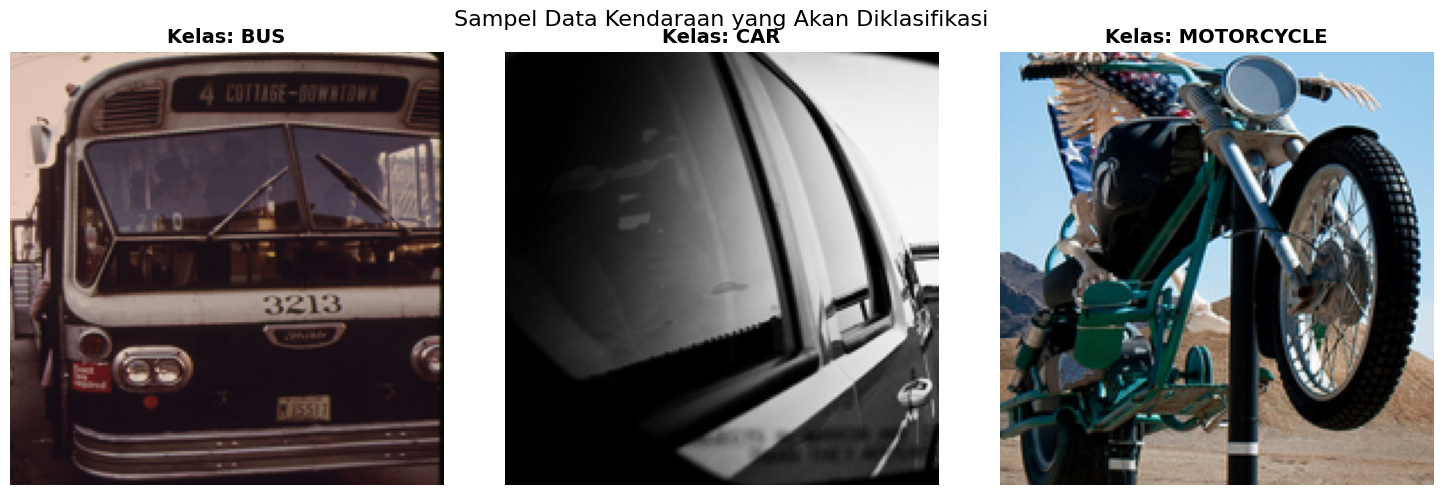

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("\nLangkah 3: Visualisasi sampel dataset")

plt.figure(figsize=(15, 5))
for i, cls in enumerate(kelas_tersedia):
    img_name = os.listdir(os.path.join(train_dir, cls))[0]
    img_path = os.path.join(train_dir, cls, img_name)

    img = mpimg.imread(img_path)
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(f"Kelas: {cls.upper()}", fontsize=14, fontweight='bold')
    plt.axis('off')

plt.suptitle("Sampel Data Kendaraan yang Akan Diklasifikasi", fontsize=16)
plt.tight_layout()
plt.show()

Blok kode ini bertujuan untuk memvisualisasikan contoh gambar dari setiap kelas:
1.  **Import Library**: Mengimpor `matplotlib.pyplot` untuk plotting dan `matplotlib.image` untuk membaca gambar.
2.  **Iterasi Kelas**: Melakukan loop melalui setiap `kelas_tersedia` (bus, car, motorcycle).
3.  **Mengambil Gambar Pertama**: Untuk setiap kelas, ia mengambil nama file gambar pertama dari direktori pelatihan.
4.  **Membaca dan Menampilkan Gambar**: Membaca gambar menggunakan `mpimg.imread` dan menampilkannya dalam subplot menggunakan `plt.imshow`.
5.  **Format Plot**: Mengatur judul subplot dengan nama kelas dan menonaktifkan sumbu untuk tampilan yang bersih. Judul utama (`plt.suptitle`) ditambahkan untuk memberikan konteks visualisasi. Ini memastikan bahwa gambar yang akan digunakan untuk pelatihan adalah yang diharapkan.

4. **Memuat Data Citra (Preprocessing)**


    Tahap ini bertujuan untuk memuat citra dari direktori penyimpanan ke dalam format TensorFlow Dataset. Penggunaan fungsi image_dataset_from_directory sangat efisien karena mampu mengelompokkan data ke dalam batch secara otomatis serta mengubah ukuran seluruh citra (resize) menjadi dimensi yang seragam, yaitu 150x150 piksel.
    
    Data training diatur agar diacak (shuffle=True) sehingga proses pembelajaran model menjadi lebih optimal dan terhindar dari bias urutan data. Sebaliknya, data validation dibiarkan berurutan (shuffle=False) untuk menjaga konsistensi posisi label pada saat evaluasi menggunakan Confusion Matrix. Parameter label_mode='categorical' ditetapkan karena klasifikasi ini melibatkan lebih dari dua kelas (Multiclass Classification).

In [ ]:
import tensorflow as tf

BATCH_SIZE = 32
IMG_SIZE = (150, 150)

print("Memuat Data Training:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode='categorical'
)

print("\nMemuat Data Validasi:")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode='categorical'
)

class_names = train_dataset.class_names
print(f"\nLabel Kelas yang digunakan model: {class_names}")

Memuat Data Training:
Found 3193 files belonging to 3 classes.

Memuat Data Validasi:
Found 427 files belonging to 3 classes.

Label Kelas yang digunakan model: ['bus', 'car', 'motorcycle']


Blok kode ini adalah tahap _preprocessing_ data citra untuk persiapan pelatihan model CNN:
1.  **Import TensorFlow**: Mengimpor pustaka TensorFlow yang diperlukan.
2.  **Definisi Konstanta**: Mengatur `BATCH_SIZE` (jumlah gambar per batch) dan `IMG_SIZE` (ukuran citra yang akan diubah menjadi 150x150 piksel).
3.  **Memuat Data Training**: Menggunakan `tf.keras.utils.image_dataset_from_directory` untuk memuat data dari `train_dir`.
    -   `shuffle=True`: Mengacak urutan data pelatihan untuk mencegah model mempelajari urutan data tertentu.
    -   `batch_size=BATCH_SIZE`: Mengelompokkan gambar menjadi batch untuk efisiensi pelatihan.
    -   `image_size=IMG_SIZE`: Mengubah ukuran semua gambar agar seragam.
    -   `label_mode='categorical'`: Mengatur label menjadi format _one-hot encoding_ yang sesuai untuk klasifikasi multi-kelas.
4.  **Memuat Data Validasi**: Memuat data dari `val_dir` dengan pengaturan yang sama, tetapi `shuffle=False` untuk menjaga konsistensi urutan label saat evaluasi menggunakan Confusion Matrix.
5.  **Mendapatkan Nama Kelas**: Mengambil dan mencetak nama-nama kelas yang terdeteksi oleh TensorFlow Dataset, yang akan digunakan oleh model.

5. **Membangun Arsitektur Convolutional Neural Network (CNN)**

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(150, 150, 3)),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,043 (496.26 KB)

 Trainable params: 127,043 (496.26 KB)

 Non-trainable params: 0 (0.00 B)

Blok kode ini mendefinisikan arsitektur Convolutional Neural Network (CNN) untuk klasifikasi citra:
1.  **Inisialisasi Model Sequential**: Membuat model sebagai urutan lapisan (`tf.keras.models.Sequential`).
2.  **Rescaling Layer**: `tf.keras.layers.Rescaling(1./255, input_shape=(150, 150, 3))` menormalisasi nilai piksel gambar dari rentang [0, 255] menjadi [0, 1]. `input_shape` mendefinisikan dimensi input gambar (tinggi, lebar, kanal warna).
3.  **Data Augmentation Layers**: `RandomFlip("horizontal")` dan `RandomRotation(0.15)` secara acak membalik horizontal dan merotasi gambar untuk meningkatkan variasi data dan mengurangi _overfitting_.
4.  **Convolutional Blocks**: Tiga blok `Conv2D` diikuti oleh `MaxPooling2D`:
    -   `Conv2D(32, (3,3), activation='relu')`: Lapisan konvolusi dengan 32 filter berukuran 3x3 piksel dan fungsi aktivasi ReLU.
    -   `MaxPooling2D(2,2)`: Lapisan _pooling_ maksimum dengan ukuran 2x2 untuk mengurangi dimensi spasial dan jumlah parameter.
    -   Jumlah filter meningkat (32 -> 64 -> 128) seiring kedalaman jaringan untuk mengekstraksi fitur yang semakin kompleks.
5.  **Global Average Pooling**: `GlobalAveragePooling2D()` menggantikan lapisan _flatten_ tradisional, mengurangi setiap peta fitur menjadi satu nilai rata-rata, membantu mengurangi jumlah parameter dan _overfitting_.
6.  **Dense Layers**: Lapisan _fully connected_:
    -   `Dense(256, activation='relu')`: Lapisan dengan 256 neuron dan aktivasi ReLU.
    -   `Dropout(0.5)`: Lapisan _dropout_ dengan _rate_ 0.5 secara acak menonaktifkan 50% neuron selama pelatihan untuk mencegah _overfitting_.
    -   `Dense(3, activation='softmax')`: Lapisan output dengan 3 neuron (sesuai jumlah kelas) dan aktivasi _softmax_ untuk probabilitas kelas multi-label.
7.  **Kompilasi Model**: `model.compile` mengkonfigurasi proses pelatihan:
    -   `optimizer='adam'`: Menggunakan algoritma optimasi Adam.
    -   `loss='categorical_crossentropy'`: Fungsi _loss_ yang sesuai untuk klasifikasi multi-kelas dengan label _one-hot encoded_.
    -   `metrics=['accuracy']`: Metrik yang digunakan untuk mengevaluasi kinerja model selama pelatihan dan pengujian.
8.  **Model Summary**: `model.summary()` mencetak ringkasan arsitektur model, termasuk jumlah parameter yang dapat dilatih (`trainable parameters`).

6. **Pelatihan Model (Training)**
    
    Tahap ini merupakan proses eksekusi pelatihan model (training) menggunakan data latih yang telah dipersiapkan. Fungsi EarlyStopping diimplementasikan sebagai callback untuk menghentikan proses pelatihan secara otomatis apabila nilai kerugian pada data validasi (val_loss) tidak menunjukkan penurunan atau perbaikan selama 5 siklus epoch berturut-turut (patience=5). Mekanisme ini berfungsi untuk menghemat waktu komputasi komputasi sekaligus mencegah terjadinya overfitting. Pengaturan restore_best_weights=True memastikan bahwa model akan menggunakan kembali pembobotan (weights) paling optimal yang dicapai sebelum pelatihan dihentikan. Proses pembelajaran model ini diatur untuk berjalan dengan batas maksimum 25 epoch.

In [ ]:
print("\nMelakukan proses training")

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    epochs=25,
    validation_data=val_dataset,
    callbacks=[early_stop]
)
print("\nProses training selesai!")


Melakukan proses training
Epoch 1/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.4557 - loss: 1.0467 - val_accuracy: 0.5644 - val_loss: 0.9256
Epoch 2/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.5465 - loss: 0.9505 - val_accuracy: 0.6276 - val_loss: 0.8523
Epoch 3/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.5800 - loss: 0.9209 - val_accuracy: 0.6159 - val_loss: 0.8466
Epoch 4/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.6195 - loss: 0.8703 - val_accuracy: 0.6604 - val_loss: 0.7824
Epoch 5/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.6082 - loss: 0.8809 - val_accuracy: 0.5972 - val_loss: 0.9669
Epoch 6/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 242s 2s/step - accuracy: 0.6264 - loss: 0.8542 - val_accuracy: 0.6768 - val_loss: 0.7635
Epoch 7/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.6414 - loss: 0.8254 - val_accuracy: 0.5738 - val_loss: 0.9542
Epoch 8/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.649

Blok kode ini menjalankan proses pelatihan (training) model CNN yang telah didefinisikan sebelumnya:
1.  **Early Stopping Callback**: `tf.keras.callbacks.EarlyStopping` dikonfigurasi untuk memantau performa model:
    -   `monitor='val_loss'`: Memantau nilai _loss_ pada data validasi.
    -   `patience=5`: Jika `val_loss` tidak membaik (menurun) selama 5 _epoch_ berturut-turut, pelatihan akan dihentikan lebih awal.
    -   `restore_best_weights=True`: Setelah pelatihan berhenti, bobot model akan dikembalikan ke _epoch_ terbaik (ketika `val_loss` paling rendah). Ini mencegah _overfitting_ dan menghemat waktu komputasi.
2.  **Pelatihan Model**: `model.fit` memulai proses pelatihan:
    -   `train_dataset`: Dataset yang digunakan untuk pelatihan.
    -   `epochs=25`: Batas maksimum _epoch_ yang akan dijalankan (bisa berhenti lebih awal karena _EarlyStopping_).
    -   `validation_data=val_dataset`: Dataset yang digunakan untuk memantau kinerja model pada data yang belum pernah dilihat selama pelatihan.
    -   `callbacks=[early_stop]`: Menerapkan _callback EarlyStopping_ yang telah didefinisikan.

7. **Evaluasi Model**


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

         bus       0.84      0.84      0.84       176
         car       0.73      0.68      0.70       106
  motorcycle       0.85      0.89      0.87       145

    accuracy                           0.81       427
   macro avg       0.80      0.80      0.80       427
weighted avg       0.81      0.81      0.81       427



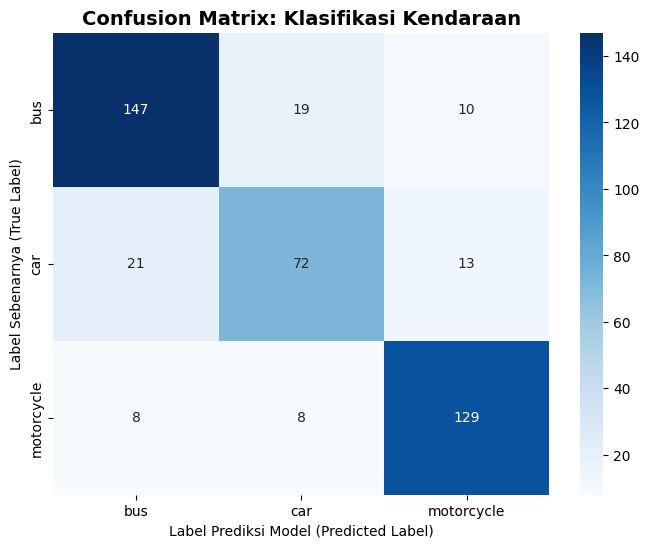

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred_classes = []
for images, labels in val_dataset:
    preds = model.predict(images, verbose=0)
    y_pred_classes.extend(np.argmax(preds, axis=1))

    y_true.extend(np.argmax(labels.numpy(), axis=1))

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Klasifikasi Kendaraan', fontsize=14, fontweight='bold')
plt.ylabel('Label Sebenarnya (True Label)')
plt.xlabel('Label Prediksi Model (Predicted Label)')
plt.show()

Blok kode ini melakukan evaluasi model yang telah dilatih menggunakan data validasi:
1.  **Import Library**: Mengimpor `numpy` untuk operasi numerik, `seaborn` untuk visualisasi, dan `classification_report`, `confusion_matrix` dari `sklearn.metrics` untuk metrik evaluasi.
2.  **Persiapan Label**: Menginisialisasi list `y_true` (label sebenarnya) dan `y_pred_classes` (kelas prediksi model).
3.  **Iterasi Dataset Validasi**: Melakukan iterasi melalui `val_dataset`:
    -   `model.predict(images, verbose=0)`: Model membuat prediksi probabilitas untuk setiap gambar dalam batch.
    -   `np.argmax(preds, axis=1)`: Mengubah probabilitas prediksi menjadi kelas prediksi (indeks probabilitas tertinggi).
    -   `np.argmax(labels.numpy(), axis=1)`: Mengambil kelas sebenarnya dari label _one-hot encoded_.
    -   Hasilnya ditambahkan ke `y_pred_classes` dan `y_true`.
4.  **Classification Report**: `classification_report` mencetak metrik performa model (presisi, _recall_, f1-score, _support_) untuk setiap kelas dan rata-ratanya, memberikan gambaran detail tentang seberapa baik model mengklasifikasikan setiap kategori.
5.  **Confusion Matrix**: `confusion_matrix(y_true, y_pred_classes)` menghitung matriks kebingungan, yang menunjukkan jumlah prediksi benar dan salah untuk setiap kelas.
6.  **Visualisasi Confusion Matrix**: `sns.heatmap` digunakan untuk membuat visualisasi _heatmap_ dari matriks kebingungan:
    -   `annot=True`, `fmt='d'`: Menampilkan nilai numerik di setiap sel matriks.
    -   `cmap='Blues'`: Mengatur skema warna.
    -   `xticklabels`, `yticklabels`: Memberikan label pada sumbu X (prediksi) dan Y (sebenarnya) dengan nama kelas.
    -   Judul dan label sumbu ditambahkan untuk kejelasan. Visualisasi ini membantu mengidentifikasi kelas mana yang sering salah diklasifikasikan.

8. **Menggunakan Dataset yang berbeda**

In [ ]:
import kagglehub
import os

path_animal = kagglehub.dataset_download("tongpython/cat-and-dog")
print(f"Dataset berhasil diunduh di:\n{path_animal}")

train_animal_dir = os.path.join(path_animal, 'training_set', 'training_set')
val_animal_dir = os.path.join(path_animal, 'test_set', 'test_set')

kelas_hewan = sorted(os.listdir(train_animal_dir))
print(f"\nDaftar Kelas Hewan: {kelas_hewan}")

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Dataset berhasil diunduh di:
/kaggle/input/cat-and-dog

Daftar Kelas Hewan: ['cats', 'dogs']


Blok kode ini mempersiapkan dataset baru untuk tugas klasifikasi yang berbeda (kucing vs anjing):
1.  **Import Library**: Mengimpor `kagglehub` untuk mengunduh dataset dan `os` untuk manipulasi jalur file.
2.  **Mengunduh Dataset Hewan**: `kagglehub.dataset_download("tongpython/cat-and-dog")` mengunduh dataset kucing dan anjing.
3.  **Mendefinisikan Direktori Dataset Hewan**: Mengatur jalur `train_animal_dir` dan `val_animal_dir` ke direktori pelatihan dan pengujian yang sesuai dalam dataset yang baru diunduh.
4.  **Mendapatkan Daftar Kelas Hewan**: `os.listdir(train_animal_dir)` digunakan untuk mendapatkan daftar folder (kelas) dalam direktori pelatihan hewan, yaitu 'cats' dan 'dogs'. Ini mengkonfirmasi kelas-kelas yang akan digunakan dalam model klasifikasi hewan.

9. **Memuat Data Citra (Preprocessing)**

    Proses selanjutnya adalah memuat citra dari direktori penyimpanan ke dalam memori menggunakan image_dataset_from_directory. Citra diubah ukurannya menjadi dimensi yang lebih kecil, yaitu 64x64 piksel. Parameter label_mode='binary' secara spesifik diterapkan karena permasalahan ini merupakan klasifikasi biner (Binary Classification), di mana hanya terdapat dua kategori kelas (kucing dan anjing). Dataset training diacak selama proses pemuatan untuk mengoptimalkan proses pembelajaran, sedangkan dataset validation dibiarkan berurutan guna menjaga konsistensi saat evaluasi akhir.

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

BATCH_SIZE = 32
IMG_SIZE_ANN = (64, 64)

train_animal_dataset = tf.keras.utils.image_dataset_from_directory(
    train_animal_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE_ANN,
    label_mode='binary'
)

val_animal_dataset = tf.keras.utils.image_dataset_from_directory(
    val_animal_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE_ANN,
    label_mode='binary'
)

class_names_animal = train_animal_dataset.class_names
print(f"\nLabel Kelas: 0 = {class_names_animal[0]}, 1 = {class_names_animal[1]}")

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.

Label Kelas: 0 = cats, 1 = dogs


Blok kode ini adalah tahap _preprocessing_ data citra untuk dataset 'cat-and-dog':
1.  **Import Library**: Mengimpor `tensorflow` untuk Dataset API dan `matplotlib.pyplot`.
2.  **Definisi Konstanta**: Mengatur `BATCH_SIZE` (32) dan `IMG_SIZE_ANN` (ukuran citra 64x64 piksel, lebih kecil karena dataset baru).
3.  **Memuat Data Training Hewan**: Menggunakan `tf.keras.utils.image_dataset_from_directory` untuk memuat data dari `train_animal_dir`:
    -   `shuffle=True`: Mengacak data pelatihan.
    -   `batch_size=BATCH_SIZE`: Mengelompokkan gambar.
    -   `image_size=IMG_SIZE_ANN`: Mengubah ukuran gambar menjadi 64x64 piksel.
    -   `label_mode='binary'`: Mengatur label menjadi format biner (0 atau 1) karena ini adalah klasifikasi dua kelas (kucing atau anjing).
4.  **Memuat Data Validasi Hewan**: Memuat data dari `val_animal_dir` dengan pengaturan yang sama, tetapi `shuffle=False` untuk konsistensi saat evaluasi.
5.  **Mendapatkan Nama Kelas Hewan**: Mengambil dan mencetak nama kelas yang terdeteksi oleh TensorFlow Dataset, mengindikasikan bahwa 'cats' akan diwakili oleh label 0 dan 'dogs' oleh label 1. Ini penting untuk interpretasi hasil model biner.

10. **Membangun Arsitektur Convolutional Neural Network (CNN)**

In [3]:
model_cnn = tf.keras.models.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(64, 64, 3)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_cnn.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

Blok kode ini membangun arsitektur CNN baru yang disesuaikan untuk tugas klasifikasi biner (kucing vs anjing):
1.  **Inisialisasi Model Sequential**: Membuat model sebagai urutan lapisan.
2.  **Rescaling Layer**: `tf.keras.layers.Rescaling(1./255, input_shape=(64, 64, 3))` menormalisasi piksel dan mengatur `input_shape` ke 64x64x3, sesuai dengan ukuran gambar baru.
3.  **Convolutional Blocks**: Tiga blok `Conv2D` diikuti oleh `MaxPooling2D` serupa dengan model sebelumnya, tetapi ukurannya mungkin sedikit berbeda karena input yang lebih kecil.
    -   `Conv2D(32, (3,3), activation='relu')`: Filter awal untuk mengekstraksi fitur dasar.
    -   `MaxPooling2D(2,2)`: Mengurangi dimensi.
    -   Jumlah filter meningkat (32 -> 64 -> 128).
4.  **Flatten Layer**: `tf.keras.layers.Flatten()` mengubah output 3D dari lapisan konvolusi menjadi vektor 1D agar dapat diumpankan ke lapisan _dense_.
5.  **Dense Layers**: Lapisan _fully connected_:
    -   `Dense(128, activation='relu')`: Lapisan dengan 128 neuron dan aktivasi ReLU.
    -   `Dropout(0.5)`: Menerapkan _dropout_ untuk mencegah _overfitting_.
    -   `Dense(1, activation='sigmoid')`: **Lapisan output tunggal** dengan aktivasi _sigmoid_. Ini adalah ciri khas klasifikasi biner, menghasilkan probabilitas tunggal antara 0 dan 1 (misalnya, probabilitas menjadi 'dog').
6.  **Kompilasi Model**: `model_cnn.compile` mengkonfigurasi pelatihan:
    -   `optimizer='adam'`: Menggunakan optimasi Adam.
    -   `loss='binary_crossentropy'`: Fungsi _loss_ yang spesifik untuk klasifikasi biner.
    -   `metrics=['accuracy']`: Metrik akurasi untuk evaluasi.
7.  **Model Summary**: `model_cnn.summary()` mencetak ringkasan arsitektur model baru, menunjukkan lapisan-lapisan dan jumlah parameternya.

11. **Training Model**

In [4]:
early_stop_cnn = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_cnn = model_cnn.fit(
    train_animal_dataset,
    epochs=20,
    validation_data=val_animal_dataset,
    callbacks=[early_stop_cnn]
)

Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 80s 307ms/step - accuracy: 0.5534 - loss: 0.6809 - val_accuracy: 0.5986 - val_loss: 0.6694
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 259ms/step - accuracy: 0.6537 - loss: 0.6286 - val_accuracy: 0.7084 - val_loss: 0.5898
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 74s 294ms/step - accuracy: 0.7154 - loss: 0.5547 - val_accuracy: 0.7266 - val_loss: 0.5460
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 72s 252ms/step - accuracy: 0.7631 - loss: 0.4950 - val_accuracy: 0.7701 - val_loss: 0.4789
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 63s 251ms/step - accuracy: 0.7935 - loss: 0.4458 - val_accuracy: 0.7731 - val_loss: 0.4838
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 63s 250ms/step - accuracy: 0.8177 - loss: 0.4020 - val_accuracy: 0.7899 - val_loss: 0.4512
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 82s 248ms/step - accuracy: 0.8485 - loss: 0.3544 - val_accuracy: 0.7958 - val_loss: 0.5077
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 63s 250ms/step - accuracy: 0.8688 - loss: 0

Blok kode ini melatih model CNN yang baru (`model_cnn`) menggunakan dataset 'cat-and-dog':
1.  **Early Stopping Callback**: `tf.keras.callbacks.EarlyStopping` dikonfigurasi sama seperti sebelumnya:
    -   `monitor='val_loss'`: Memantau _loss_ pada data validasi.
    -   `patience=5`: Menghentikan pelatihan jika tidak ada perbaikan dalam 5 _epoch_.
    -   `restore_best_weights=True`: Mengembalikan bobot terbaik.
2.  **Pelatihan Model**: `model_cnn.fit` memulai proses pelatihan:
    -   `train_animal_dataset`: Dataset pelatihan untuk kucing dan anjing.
    -   `epochs=20`: Batas maksimum _epoch_ (lebih rendah dari sebelumnya karena dataset yang berbeda atau konvergensi yang lebih cepat).
    -   `validation_data=val_animal_dataset`: Dataset validasi untuk kucing dan anjing.
    -   `callbacks=[early_stop_cnn]`: Menerapkan _callback EarlyStopping_.

Output menunjukkan kemajuan pelatihan per _epoch_, termasuk _loss_ dan akurasi untuk data pelatihan dan validasi. Ini memungkinkan pemantauan seberapa baik model belajar dan menggeneralisasi ke data baru.

12. **Evaluasi Model**

              precision    recall  f1-score   support

        cats       0.79      0.84      0.82      1011
        dogs       0.83      0.78      0.81      1012

    accuracy                           0.81      2023
   macro avg       0.81      0.81      0.81      2023
weighted avg       0.81      0.81      0.81      2023



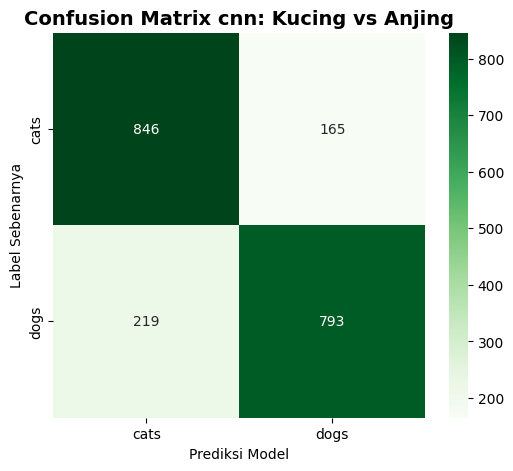

In [5]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


y_true_cnn = []
y_pred_probs = []

for images, labels in val_animal_dataset:
    preds = model_cnn.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true_cnn.extend(labels.numpy())

y_pred_classes_cnn = [1 if prob > 0.5 else 0 for prob in y_pred_probs]

print(classification_report(y_true_cnn, y_pred_classes_cnn, target_names=class_names_animal))

cm_cnn = confusion_matrix(y_true_cnn, y_pred_classes_cnn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names_animal, yticklabels=class_names_animal)
plt.title('Confusion Matrix cnn: Kucing vs Anjing', fontsize=14, fontweight='bold')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')
plt.show()

Blok kode ini mengevaluasi kinerja model CNN (`model_cnn`) untuk klasifikasi kucing dan anjing:
1.  **Import Library**: Mengimpor `numpy`, `seaborn`, `classification_report`, dan `confusion_matrix`.
2.  **Persiapan Label Biner**: Menginisialisasi `y_true_cnn` (label sebenarnya) dan `y_pred_probs` (probabilitas prediksi model).
3.  **Iterasi Dataset Validasi**: Melakukan loop melalui `val_animal_dataset`:
    -   `model_cnn.predict(images, verbose=0)`: Model membuat prediksi probabilitas (nilai antara 0 dan 1) untuk setiap gambar.
    -   `y_pred_probs.extend(preds)`: Menyimpan probabilitas mentah.
    -   `y_true_cnn.extend(labels.numpy())`: Menyimpan label sebenarnya (0 atau 1).
4.  **Mengkonversi Probabilitas ke Kelas**: `y_pred_classes_cnn = [1 if prob > 0.5 else 0 for prob in y_pred_probs]` mengubah probabilitas prediksi menjadi kelas biner (1 jika probabilitas > 0.5, jika tidak 0).
5.  **Classification Report**: `classification_report` mencetak metrik performa (presisi, _recall_, f1-score, _support_) untuk kelas 'cats' dan 'dogs', serta rata-ratanya. Ini memberikan analisis terperinci tentang kemampuan model untuk mengklasifikasikan setiap kategori secara akurat.
6.  **Confusion Matrix**: `confusion_matrix(y_true_cnn, y_pred_classes_cnn)` menghitung matriks kebingungan.
7.  **Visualisasi Confusion Matrix**: `sns.heatmap` digunakan untuk memvisualisasikan matriks kebingungan:
    -   `annot=True`, `fmt='d'`: Menampilkan jumlah numerik.
    -   `cmap='Greens'`: Menggunakan skema warna hijau.
    -   `xticklabels`, `yticklabels`: Memberikan label 'cats' dan 'dogs' pada sumbu untuk interpretasi yang jelas. Visualisasi ini secara intuitif menunjukkan di mana model melakukan kesalahan dan kelas mana yang sering membingungkan model.

13. **Visualisasi Hasil**

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_1060/1644039162.py:1: SyntaxWarning: invalid escape sequence '\M'
  print("\Menampilkan Visualisasi Prediksi 20 Gambar")


\Menampilkan Visualisasi Prediksi 20 Gambar


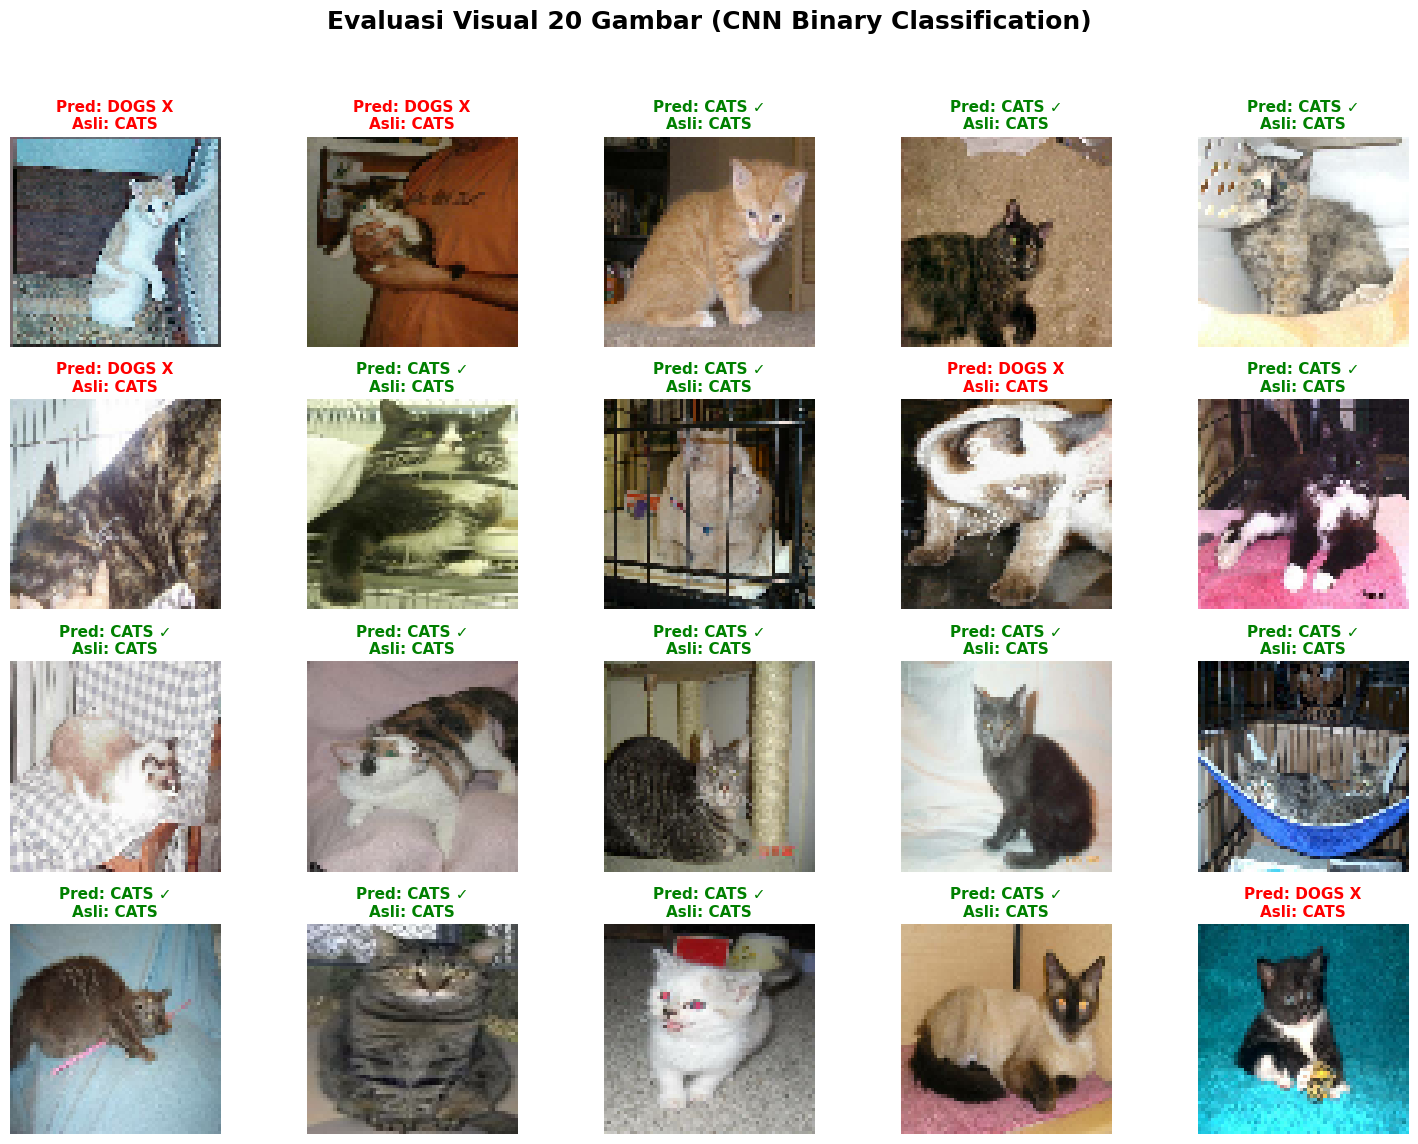

In [6]:
print("\Menampilkan Visualisasi Prediksi 20 Gambar")

for images, labels in val_animal_dataset.take(1):
    images_to_show = images[:20]
    labels_to_show = labels[:20].numpy()

    preds = model_cnn.predict(images_to_show, verbose=0)

    plt.figure(figsize=(15, 12))

    for i in range(20):
        plt.subplot(4, 5, i + 1)

        img = images_to_show[i].numpy().astype("uint8")
        plt.imshow(img)

        true_label = int(labels_to_show[i][0])

        pred_prob = preds[i][0]
        pred_label = 1 if pred_prob > 0.5 else 0

        true_name = class_names_animal[true_label].upper()
        pred_name = class_names_animal[pred_label].upper()

        if true_label == pred_label:
            text_color = 'green'
            status = "✓"
        else:
            text_color = 'red'
            status = "X"

        plt.title(f"Pred: {pred_name} {status}\nAsli: {true_name}",
                  color=text_color, fontsize=11, fontweight='bold')
        plt.axis("off")

    plt.suptitle("Evaluasi Visual 20 Gambar (CNN Binary Classification)",
                 fontsize=18, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    break

Blok kode ini menyediakan visualisasi langsung dari hasil prediksi model pada sampel gambar:
1.  **Mengambil Sampel Gambar**: `val_animal_dataset.take(1)` mengambil satu batch pertama dari dataset validasi. Kemudian, 20 gambar pertama (`images[:20]`) dan labelnya (`labels[:20].numpy()`) disiapkan untuk ditampilkan.
2.  **Prediksi Model**: `model_cnn.predict(images_to_show, verbose=0)` menghasilkan prediksi untuk 20 gambar yang dipilih.
3.  **Loop Visualisasi**: Melakukan iterasi untuk setiap dari 20 gambar:
    -   `plt.subplot(4, 5, i + 1)`: Membuat grid 4x5 untuk menampilkan gambar.
    -   `plt.imshow(img)`: Menampilkan gambar asli.
    -   **Penentuan Label**: Mengambil label sebenarnya (`true_label`) dan mengkonversi probabilitas prediksi (`pred_prob`) menjadi label prediksi biner (`pred_label`).
    -   **Perbandingan dan Status**: Membandingkan label sebenarnya dan prediksi. Jika cocok, `text_color` diatur menjadi hijau dan `status` menjadi '✓'; jika tidak, `text_color` merah dan `status` 'X'.
    -   **Judul Gambar**: `plt.title` menampilkan label prediksi dan sebenarnya, bersama dengan status benar/salah, menggunakan warna yang sesuai. `plt.axis("off")` menghilangkan sumbu untuk tampilan yang bersih.
4.  **Judul Utama dan Tata Letak**: `plt.suptitle` menambahkan judul utama untuk seluruh plot, dan `plt.tight_layout` menyesuaikan spasi agar semua elemen terlihat jelas.
5.  **`break`**: Menghentikan loop setelah batch pertama diproses, karena tujuannya hanya menampilkan beberapa sampel.

Visualisasi ini sangat berguna untuk pemeriksaan kualitatif model, memungkinkan kita melihat contoh spesifik di mana model berkinerja baik atau buruk.